# Initialization


In [95]:
import slangpy as spy
import pathlib
import numpy as np
import os

# Get file directory either for .py or .ipynb
try:
    # Works in a standard .py script
    current_dir = pathlib.Path(__file__).resolve().parent.absolute
except NameError:
    # Fallback for Jupyter Notebooks
    current_dir = pathlib.Path(globals()['_dh'][0])


# Create a SlangPy device and use the local folder for Slang includes
device = spy.create_device(include_paths=[
        current_dir
])

# Load the module
module = spy.Module.load_from_file(device, "example.slang")

# Creating Tensors
We’ll now create and initialize two tensors of type Pixel. The first will use a tensor cursor for manual population, while the second will be populated using a NumPy array.

In [96]:
# Create two 2D tensors of size 16x16
image_1 = spy.Tensor.empty(device, dtype=module.Pixel, shape=(16, 16))
image_2 = spy.Tensor.empty(device, dtype=module.Pixel, shape=(16, 16))

# Populate the first tensor using a cursor
cursor_1 = image_1.cursor()
for x in range(16):
    for y in range(16):
        cursor_1[x + y * 16].write({
            'r': 0,
            'g': 0,
            'b': 255 / 32.0
            # 'b': (x + y) / 32.0
        })
cursor_1.apply()

# Populate the second tensor directly from a NumPy array
image_2.copy_from_numpy(0.1 * np.random.rand(16 * 16 * 3).astype(np.float32))

# Calling the Function
Once our data is ready, we can call the add function as usual:

In [97]:
# Call the module's add function
result = module.add(image_1, image_2)

# Reading the Results
Finally, let’s print the result and, if available, use tev to visualize it:

In [98]:
# Read and print pixel data using a cursor
result_cursor = result.cursor()
# for x in range(16):
#     for y in range(16):
#         pixel = result_cursor[x + y * 16].read()
#         print(f"Pixel ({x},{y}): {pixel}")
# Read and print pixel data using a cursor
line=""
result_cursor = result.cursor()
for x in range(16):
    for y in range(16):
        pixel = result_cursor[x + y * 16].read()
        # print(f"Pixel ({x},{y}): {pixel}")
        line += f"{x},{y}|{pixel['r']:.2f},{pixel['g']:.2f},{pixel['b']:.2f}\t"
    line += "\n"

print(line)

# Display the result with tev (https://github.com/Tom94/tev)
tex = device.create_texture(
    data=result.to_numpy(),
    width=16,
    height=16,
    format=spy.Format.rgb32_float
)
spy.tev.show(tex)

0,0|0.01,0.07,8.04	0,1|0.05,0.04,8.04	0,2|0.02,0.10,8.02	0,3|0.06,0.05,8.04	0,4|0.09,0.04,8.02	0,5|0.07,0.07,7.98	0,6|0.08,0.02,8.01	0,7|0.05,0.00,8.05	0,8|0.02,0.04,7.99	0,9|0.01,0.08,8.06	0,10|0.08,0.02,7.98	0,11|0.10,0.09,8.00	0,12|0.07,0.06,8.03	0,13|0.08,0.06,8.00	0,14|0.05,0.04,7.98	0,15|0.01,0.05,7.99	
1,0|0.02,0.09,7.99	1,1|0.08,0.04,8.00	1,2|0.07,0.02,8.04	1,3|0.01,0.00,8.06	1,4|0.03,0.07,8.01	1,5|0.07,0.10,8.05	1,6|0.10,0.04,7.97	1,7|0.10,0.02,7.98	1,8|0.09,0.08,8.06	1,9|0.03,0.07,8.00	1,10|0.02,0.04,8.03	1,11|0.04,0.03,7.99	1,12|0.01,0.01,8.03	1,13|0.04,0.03,8.04	1,14|0.07,0.06,8.01	1,15|0.06,0.04,8.00	
2,0|0.02,0.04,8.06	2,1|0.09,0.04,7.98	2,2|0.03,0.03,7.99	2,3|0.09,0.04,8.03	2,4|0.08,0.07,8.05	2,5|0.05,0.06,7.99	2,6|0.05,0.05,8.04	2,7|0.10,0.09,8.02	2,8|0.05,0.07,8.05	2,9|0.08,0.09,7.99	2,10|0.06,0.02,8.01	2,11|0.09,0.06,8.00	2,12|0.08,0.06,7.97	2,13|0.04,0.06,8.00	2,14|0.00,0.09,8.06	2,15|0.07,0.01,8.06	
3,0|0.09,0.01,7.99	3,1|0.09,0.03,8.05	3,2|0.04,0.10,8.05	3,3|0.04,0

True

[WARN] Failed to connect to tev (attempt 1/3): connect() failed: Connection refused (111)
[WARN] Failed to connect to tev (attempt 2/3): connect() failed: Connection refused (111)
[WARN] Failed to connect to tev (attempt 3/3): connect() failed: Connection refused (111)
[WARN] Failed to connect to tev after 3 attempts. Make sure the tev image viewer (https://github.com/Tom94/tev) is running.


# Second part with Tensors

In [99]:
# Load the module
module = spy.Module.load_from_file(device, "example2.slang")

In [100]:
# Call the module's add function using a grid generator
result = spy.Tensor.empty(device, dtype=module.Pixel, shape=(16, 16))
module.add(
    spy.grid(shape=(16, 16)),
    image_1,
    image_2,
    result
)
# Read and print pixel data using a cursor
result_cursor = result.cursor()
# for x in range(16):
#     for y in range(16):
#         pixel = result_cursor[x + y * 16].read()
#         print(f"Pixel ({x},{y}): {pixel}")
# Read and print pixel data using a cursor
line=""
result_cursor = result.cursor()
for x in range(16):
    for y in range(16):
        pixel = result_cursor[x + y * 16].read()
        # print(f"Pixel ({x},{y}): {pixel}")
        line += f"{x},{y}|{pixel['r']:.2f},{pixel['g']:.2f},{pixel['b']:.2f}\t"
    line += "\n"

print(line)

# Display the result with tev (https://github.com/Tom94/tev)
tex = device.create_texture(
    data=result.to_numpy(),
    width=16,
    height=16,
    format=spy.Format.rgb32_float
)
spy.tev.show(tex)

0,0|0.01,0.07,8.04	0,1|0.05,0.04,8.04	0,2|0.02,0.10,8.02	0,3|0.06,0.05,8.04	0,4|0.09,0.04,8.02	0,5|0.07,0.07,7.98	0,6|0.08,0.02,8.01	0,7|0.05,0.00,8.05	0,8|0.02,0.04,7.99	0,9|0.01,0.08,8.06	0,10|0.08,0.02,7.98	0,11|0.10,0.09,8.00	0,12|0.07,0.06,8.03	0,13|0.08,0.06,8.00	0,14|0.05,0.04,7.98	0,15|0.01,0.05,7.99	
1,0|0.02,0.09,7.99	1,1|0.08,0.04,8.00	1,2|0.07,0.02,8.04	1,3|0.01,0.00,8.06	1,4|0.03,0.07,8.01	1,5|0.07,0.10,8.05	1,6|0.10,0.04,7.97	1,7|0.10,0.02,7.98	1,8|0.09,0.08,8.06	1,9|0.03,0.07,8.00	1,10|0.02,0.04,8.03	1,11|0.04,0.03,7.99	1,12|0.01,0.01,8.03	1,13|0.04,0.03,8.04	1,14|0.07,0.06,8.01	1,15|0.06,0.04,8.00	
2,0|0.02,0.04,8.06	2,1|0.09,0.04,7.98	2,2|0.03,0.03,7.99	2,3|0.09,0.04,8.03	2,4|0.08,0.07,8.05	2,5|0.05,0.06,7.99	2,6|0.05,0.05,8.04	2,7|0.10,0.09,8.02	2,8|0.05,0.07,8.05	2,9|0.08,0.09,7.99	2,10|0.06,0.02,8.01	2,11|0.09,0.06,8.00	2,12|0.08,0.06,7.97	2,13|0.04,0.06,8.00	2,14|0.00,0.09,8.06	2,15|0.07,0.01,8.06	
3,0|0.09,0.01,7.99	3,1|0.09,0.03,8.05	3,2|0.04,0.10,8.05	3,3|0.04,0

True

In [101]:
import matplotlib.pyplot as plt


In [102]:
data_2d = result.to_numpy()


In [103]:
data_2d.shape

(16, 16, 12)

In [104]:
rgb_data = data_2d[:, :, [0, 1, 2]]

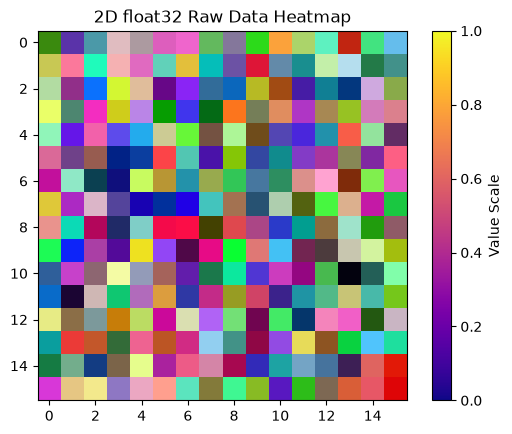

In [105]:
# Plot using a colormap (e.g., 'viridis')
plt.imshow(rgb_data, cmap='plasma', interpolation='nearest', vmin=0.0, vmax=1.0)
plt.colorbar(label="Value Scale")  # Shows how float32 map to colors
plt.title("2D float32 Raw Data Heatmap")
plt.show()